# Fake news detection - Data Processing Steps

* Load both CSV files
* Add a label column (FAKE or REAL)
* Combine into a single dataset

In [8]:
# import libraries
import pandas as pd
import numpy as np
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from scipy.sparse import hstack
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from gensim.models import Word2Vec
from scipy.sparse import hstack


# Make sure you have the required resources
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/sumantarout/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/sumantarout/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/sumantarout/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/sumantarout/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [9]:
# datasets
df_fake = pd.read_csv("Fake.csv")
df_true = pd.read_csv("True.csv")

# Add label columns
df_fake["label"] = "FAKE"
df_true["label"] = "REAL"

# Combine into one dataset
df_combined = pd.concat([df_fake, df_true], ignore_index=True)

# Check result
print(df_combined.head())


                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   
3   Trump Is So Obsessed He Even Has Obama’s Name...   
4   Pope Francis Just Called Out Donald Trump Dur...   

                                                text subject  \
0  Donald Trump just couldn t wish all Americans ...    News   
1  House Intelligence Committee Chairman Devin Nu...    News   
2  On Friday, it was revealed that former Milwauk...    News   
3  On Christmas day, Donald Trump announced that ...    News   
4  Pope Francis used his annual Christmas Day mes...    News   

                date label  
0  December 31, 2017  FAKE  
1  December 31, 2017  FAKE  
2  December 30, 2017  FAKE  
3  December 29, 2017  FAKE  
4  December 25, 2017  FAKE  


In [10]:
print(df_combined["label"].value_counts())

label
FAKE    23481
REAL    21417
Name: count, dtype: int64


In [11]:
print(df_combined.columns)

Index(['title', 'text', 'subject', 'date', 'label'], dtype='object')


### Kaggle Fake News datasets has the following columns
- 'title', 'text', 'subject', 'date', 'label', 'clean_text'

#### text → Must process (main news article body).

#### title → Optional. Titles sometimes carry strong signals for fake/real detection. You can:

- Process it the same way as text
- Or merge it with text → e.g., df_combined["full_text"] = df_combined["title"] + " " + df_combined["text"]

#### subject → Usually categorical (like politics, world news, etc.). You can:

- Keep it as a separate feature
- Or drop it if you want pure text classification

#### date → Rarely useful for NLP directly. You can drop it unless you want to analyze trends over time.

#### label → Target column (FAKE / REAL). Keep as is (This was added by ue)

### Best practice for Fake News classification:
- Process title + text together into one clean column.
- Drop subject and date (unless you want to experiment with them later).

## Data Preprocessing
- Lowercase text
- Remove punctuation and stopwords
- Lemmatize (or stem) words

In [12]:
# Initialize tools
stop_words = set(stopwords.words('english'))

In [13]:
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # 1. Lowercase
    text = text.lower()
    
    # 2. Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))
    
    # 3. Tokenize (simple split instead of nltk.word_tokenize)
    tokens = text.split()
    
    # 4. Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]
    
    # 5. Lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    
    return " ".join(tokens)

# Apply to your combined dataset (assuming text column is named 'text')
df_combined["clean_text"] = df_combined["text"].apply(preprocess_text)

# Check result
print(df_combined[["text", "clean_text"]].head())

                                                text  \
0  Donald Trump just couldn t wish all Americans ...   
1  House Intelligence Committee Chairman Devin Nu...   
2  On Friday, it was revealed that former Milwauk...   
3  On Christmas day, Donald Trump announced that ...   
4  Pope Francis used his annual Christmas Day mes...   

                                          clean_text  
0  donald trump wish american happy new year leav...  
1  house intelligence committee chairman devin nu...  
2  friday revealed former milwaukee sheriff david...  
3  christmas day donald trump announced would bac...  
4  pope francis used annual christmas day message...  


# Exploratory data analysis (EDA)

/var/folders/m5/6x27s8j117j3ftm9jhxmh1h00000gn/T/ipykernel_22721/1792799568.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="label", data=df, palette="Set2")


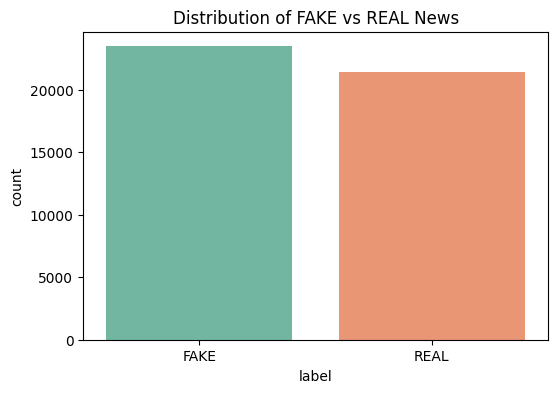

/var/folders/m5/6x27s8j117j3ftm9jhxmh1h00000gn/T/ipykernel_22721/1792799568.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y="subject", data=df, order=df["subject"].value_counts().index, palette="Set3")


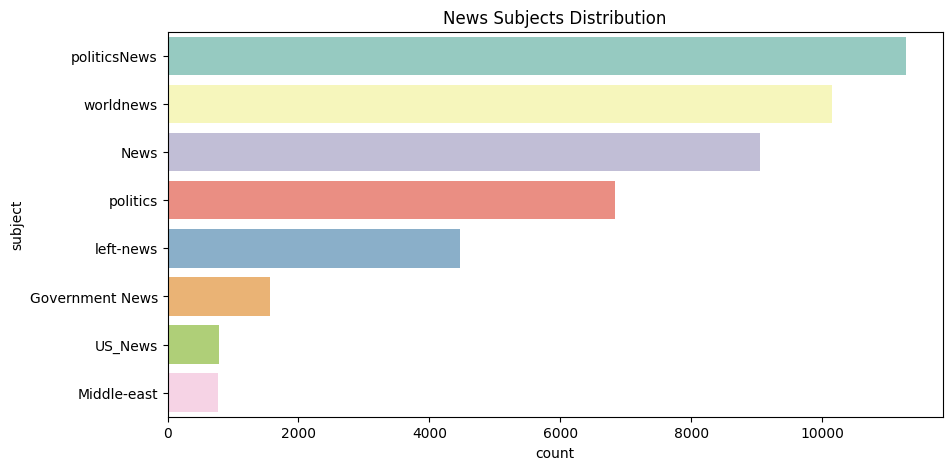

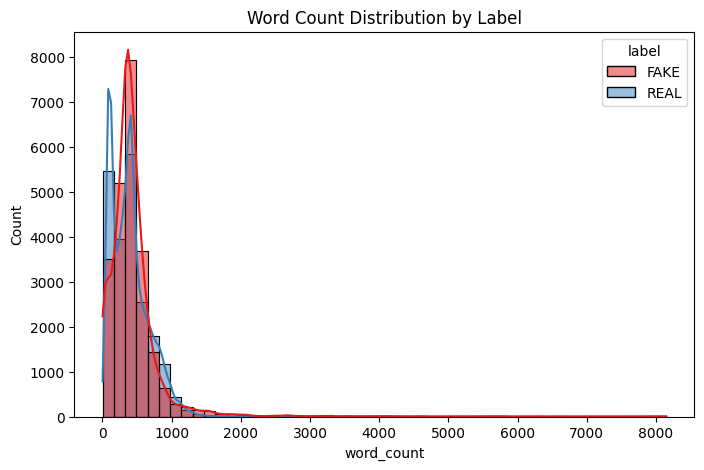

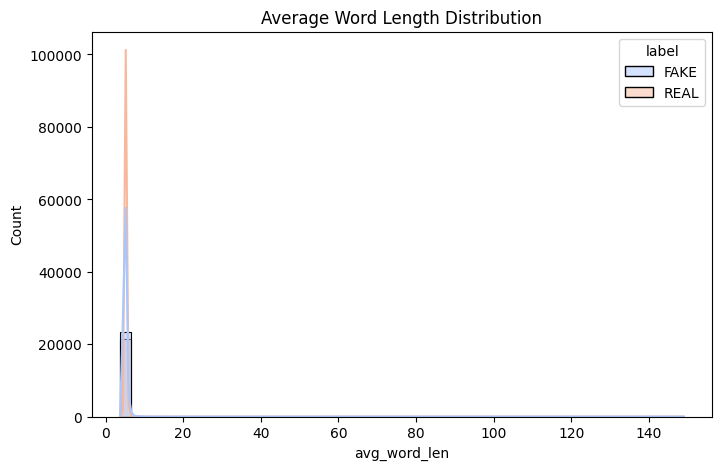

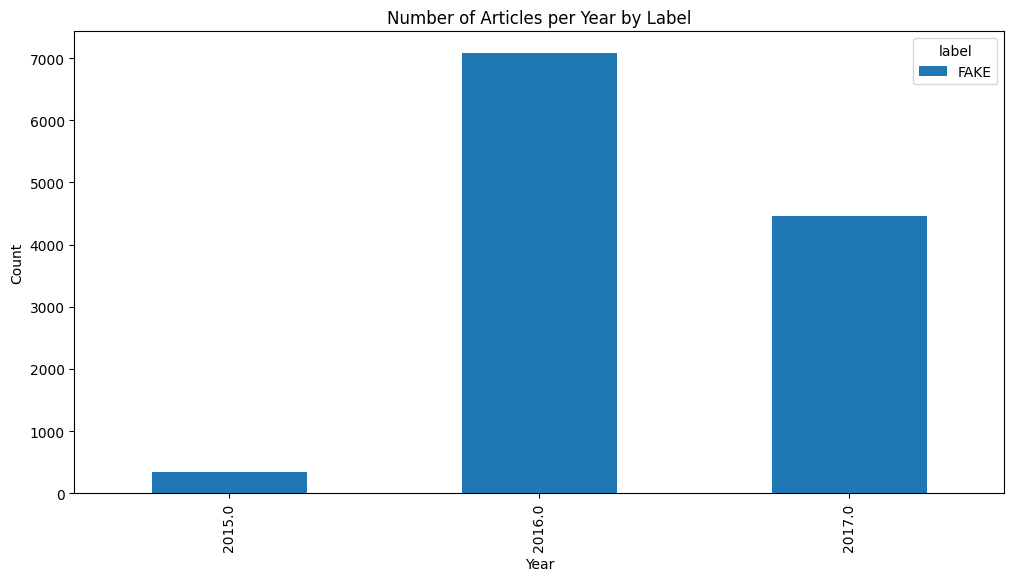

Generating Word Clouds and Top-N Words...


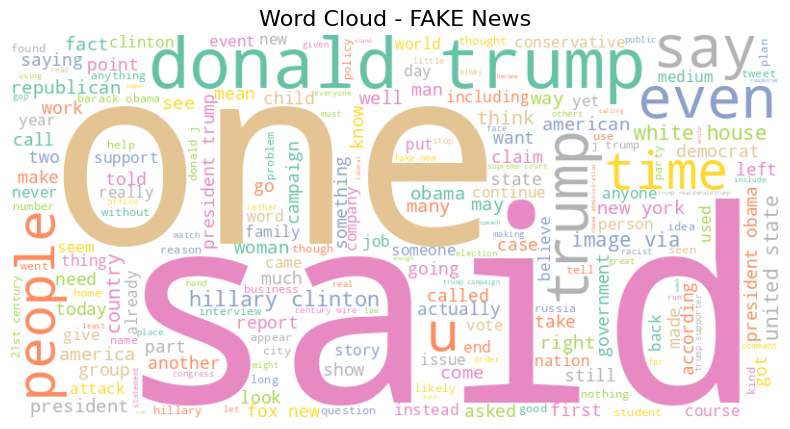

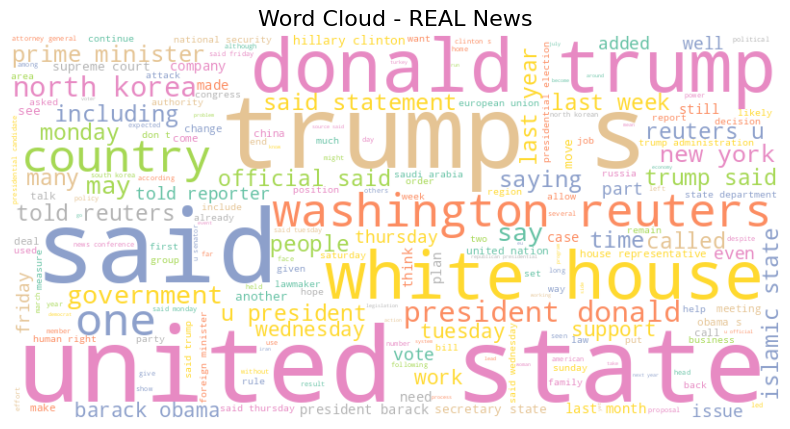

/var/folders/m5/6x27s8j117j3ftm9jhxmh1h00000gn/T/ipykernel_22721/1792799568.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette="viridis")


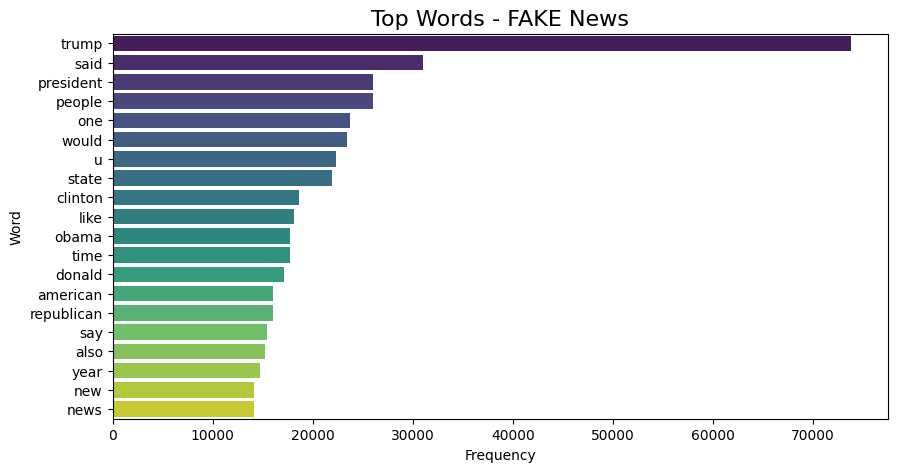

/var/folders/m5/6x27s8j117j3ftm9jhxmh1h00000gn/T/ipykernel_22721/1792799568.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette="viridis")


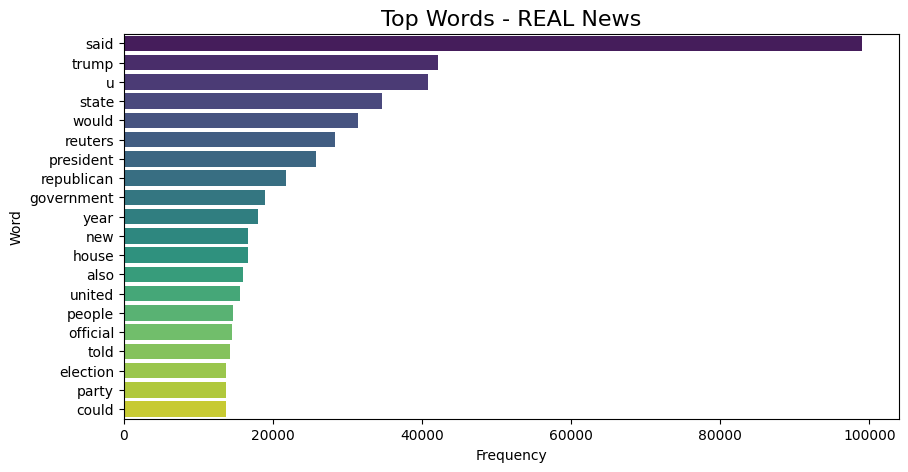

In [14]:
def run_eda(df, n_top_words=20):
    # --- Ensure full_text exists ---
    if "full_text" not in df.columns:
        df["full_text"] = df["title"].fillna("") + " " + df["text"].fillna("")
    
    # --- Word count & average word length ---
    df["word_count"] = df["full_text"].apply(lambda x: len(str(x).split()))
    df["avg_word_len"] = df["full_text"].apply(
        lambda x: sum(len(w) for w in str(x).split())/len(str(x).split()) if len(str(x).split())>0 else 0
    )

    # --- 1. Distribution of labels ---
    plt.figure(figsize=(6,4))
    sns.countplot(x="label", data=df, palette="Set2")
    plt.title("Distribution of FAKE vs REAL News")
    plt.show()

    # --- 2. Distribution of subjects ---
    if "subject" in df.columns:
        plt.figure(figsize=(10,5))
        sns.countplot(y="subject", data=df, order=df["subject"].value_counts().index, palette="Set3")
        plt.title("News Subjects Distribution")
        plt.show()

    # --- 3. Word count distribution ---
    plt.figure(figsize=(8,5))
    sns.histplot(data=df, x="word_count", hue="label", bins=50, kde=True, palette="Set1")
    plt.title("Word Count Distribution by Label")
    plt.show()

    # --- 4. Average word length ---
    plt.figure(figsize=(8,5))
    sns.histplot(data=df, x="avg_word_len", hue="label", bins=50, kde=True, palette="coolwarm")
    plt.title("Average Word Length Distribution")
    plt.show()

    # --- 5. Time series by year ---
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
        df_yearly = df.groupby([df["date"].dt.year, "label"]).size().unstack()
        if not df_yearly.empty:
            df_yearly.plot(kind="bar", stacked=True, figsize=(12,6))
            plt.title("Number of Articles per Year by Label")
            plt.xlabel("Year")
            plt.ylabel("Count")
            plt.show()

    # --- Helper functions ---
    def plot_wordcloud(text, title):
        wc = WordCloud(width=800, height=400, background_color="white", colormap="Set2").generate(" ".join(text))
        plt.figure(figsize=(10,5))
        plt.imshow(wc, interpolation="bilinear")
        plt.axis("off")
        plt.title(title, fontsize=16)
        plt.show()

    def plot_top_words(text, title, n=20):
        words = " ".join(text).split()
        counter = Counter(words)
        common_words = counter.most_common(n)
        words, counts = zip(*common_words)
        
        plt.figure(figsize=(10,5))
        sns.barplot(x=list(counts), y=list(words), palette="viridis")
        plt.title(title, fontsize=16)
        plt.xlabel("Frequency")
        plt.ylabel("Word")
        plt.show()

    # --- Separate FAKE and REAL cleaned text ---
    if "clean_text" in df.columns:
        print("Generating Word Clouds and Top-N Words...")

        fake_texts = df[df["label"]=="FAKE"]["clean_text"]
        real_texts = df[df["label"]=="REAL"]["clean_text"]

        # Word Clouds
        plot_wordcloud(fake_texts, "Word Cloud - FAKE News")
        plot_wordcloud(real_texts, "Word Cloud - REAL News")

        # Top-N Words
        plot_top_words(fake_texts, "Top Words - FAKE News", n=n_top_words)
        plot_top_words(real_texts, "Top Words - REAL News", n=n_top_words)

# Run the EDA function
run_eda(df_combined, n_top_words=20)

### Label Distribution (FAKE vs REAL)
- Balance between fake and real news articles.
#### Interpretation
- If bars are roughly equal → balanced dataset → good for training.
- If one label dominates (e.g., FAKE >> REAL) → imbalanced dataset → may bias models; you’d need resampling/weighting techniques.

### Subject Distribution
- The frequency of each news category (politics, world news, etc.).
#### Interpretation:
- Subjects with very high counts dominate the dataset.
- If FAKE and REAL are distributed differently across subjects, then the model may learn topic bias (e.g., maybe most FAKE news is in politics).
- We should check whether label imbalance correlates with subject.

### Word Count Distribution
- Length of articles (number of words) for FAKE vs REAL.

#### Interpretation

- If FAKE articles are generally shorter/longer than REAL ones, that’s a distinguishing feature.
- A large overlap means length is not strongly discriminative.
- Outliers (very long/short articles) may be errors or special cases.

### Average Word Length
- Typical word size in articles.

#### Interpret

- If FAKE uses shorter words → simpler language → could indicate attempts to reach wider audiences.
- If REAL uses longer words → more formal/professional language.
- Similar distributions mean this feature alone won’t separate FAKE vs REAL.

### Articles Over Time (if date exists)
- Trends of publishing volume across years/months.

#### Interpretation
- Spikes may indicate major events where fake news surged (e.g., elections, pandemics).
- If FAKE and REAL have similar trends → temporal features may not matter much.
- If FAKE peaks during specific times → could be useful for time-aware models.

### Word Clouds (FAKE vs REAL)
- The most frequent words in FAKE or REAL news text.

#### Interpretation
- Bigger words = more frequent in that group.
- If FAKE word cloud shows sensational or emotional words (shocking, breaking, unbelievable), that suggests fake news tends to use clickbait-style language.
- REAL word cloud may highlight more neutral/professional terms (said, report, government, official).
- Insight: Word choice can reveal writing style differences between fake and real news.


### Top-N Word Bar Charts (FAKE vs REAL)
- Exact frequencies of the top N words.

#### Interpretation

- Unlike word clouds, bar charts give you numbers → you can directly compare FAKE vs REAL.
- Example: If trump appears 5000 times in FAKE but only 1000 times in REAL → fake news may overemphasize certain political figures.
- Compare overlap: if both FAKE and REAL share common words (said, people, time), those aren’t discriminative.
- Insight: Helps you spot which words are uniquely frequent in FAKE vs REAL, guiding feature selection.

# Feature Engineering
### TF-IDF (Term Frequency – Inverse Document Frequency)
- It’s a method to measure how important a word is in a document compared to the whole dataset (corpus).
- Unlike raw counts, TF-IDF down-weights common words (like “the”, “is”, “said”) and highlights unique, informative words.

#### TF: How often a word appears in a document
- Formula
  - TF(t,d )= Number of times term t appears in document d​ / Total terms in document d 

Example:

Document: "Breaking news shocking event shocking discovery"

Term: "shocking"

TF = 2 / 6 = 0.33

#### IDF (Inverse Document Frequency): How unique a word is across all documents.
- Formula
  - IDF(t)=log[(Total number of documents)/(Number of documents containing term t)​]

Example:
- If a word appears in every document → IDF ≈ 0 (not useful).
- If a word appears in few documents → IDF is high (important signal).

Term: "shocking"

Total docs = 100

"shocking" appears in 5 docs

IDF = log(100 / 5) ≈ 2.0

#### TF-IDF: Multiply TF and IDF

Example:

Term: "shocking" => 0.33 × 2.0 = 0.66
A common word like "the" would have very low score since IDF ≈ 0.

In [15]:
# TF-IDF
def extract_tfidf(df, max_features=5000, ngram_range=(1,2)):
    vectorizer = TfidfVectorizer(max_features=max_features, stop_words="english", ngram_range=ngram_range)
    X = vectorizer.fit_transform(df["full_text"])
    return X, vectorizer
# X_tfidf, tfidf_vectorizer = extract_tfidf(df_combined)

#### Bag of Words (BOW)
- Classic count of words.

In [16]:

def extract_bow(df, max_features=5000):
    vectorizer = CountVectorizer(max_features=max_features, stop_words="english")
    X = vectorizer.fit_transform(df["full_text"])
    return X, vectorizer

### Word2Vec (Dense word embeddings)
- Instead of sparse vectors, we average pretrained word vectors for each article.

In [17]:
import gensim.downloader as api
import numpy as np

# Load pretrained Word2Vec (GoogleNews is heavy, you can start with "glove-wiki-gigaword-50")
w2v_model = api.load("glove-wiki-gigaword-50")

def document_vector(doc, model=w2v_model):
    """Average word embeddings for each document"""
    words = [w for w in doc.split() if w in model.key_to_index]
    if len(words) == 0:
        return np.zeros(model.vector_size)
    return np.mean(model[words], axis=0)

def extract_word2vec(df):
    X = np.vstack(df["clean_text"].apply(lambda x: document_vector(x)))
    return X


### Meta Data Features
##### word_count

- Counts the total number of words in each article/text.

Example:

"Breaking news shocking event" → 4

Why useful?

Fake news often uses shorter or longer exaggerated headlines compared to real news.

Word count can capture such structural differences.

##### avg_word_len

- Computes the average length of words in the text.

Example:

"Breaking news shocking event" → lengths [8, 4, 8, 5] → avg = 6.25

Why useful?

Fake news may use simpler, shorter words (to appeal broadly),
while real news may use more complex vocabulary.

This feature helps capture language complexity.

#### Why add these?

- Your TF-IDF / BOW / Word2Vec only focus on content of words.
   - But metadata features capture style and structure:

- Article length

- Vocabulary richness

- Simplicity/complexity

- By combining these with TF-IDF vectors, the model learns not just what words are used, but how they are written → giving stronger signals to detect fake vs real.

#### Summary: 
- word_count = how long is the text?

- avg_word_len = how complex are the words?

- These become extra numerical features appended to your vectorized text.

In [18]:
def add_metadata_features(df):
    # Word count in full_text
    df["word_count"] = df["full_text"].apply(lambda x: len(str(x).split()))

    # Average word length
    df["avg_word_len"] = df["full_text"].apply(
        lambda x: np.mean([len(w) for w in str(x).split()]) if len(str(x).split()) > 0 else 0
    )

    # Title length (in characters)
    df["title_len"] = df["title"].apply(lambda x: len(str(x)))

    # Count of exclamation marks in full_text
    df["exclaim_count"] = df["full_text"].apply(lambda x: str(x).count("!"))

    # Count of question marks in full_text
    df["question_count"] = df["full_text"].apply(lambda x: str(x).count("?"))

    return df


### Feature extraction

In [19]:

def extract_features(df, method="tfidf", max_features=5000):
    texts = df["full_text"]

    if method == "bow":
        vectorizer = CountVectorizer(max_features=max_features, stop_words="english")
        X = vectorizer.fit_transform(texts)
        return X, vectorizer

    elif method == "tfidf":
        vectorizer = TfidfVectorizer(max_features=max_features, stop_words="english")
        X = vectorizer.fit_transform(texts)
        return X, vectorizer

    elif method == "tfidf_meta":
        vectorizer = TfidfVectorizer(max_features=max_features, stop_words="english")
        X_tfidf = vectorizer.fit_transform(texts)

        df = add_metadata_features(df)
        meta = df[["word_count", "avg_word_len", "title_len", "exclaim_count", "question_count"]].values

        scaler = StandardScaler()
        meta_scaled = scaler.fit_transform(meta)

        X = hstack([X_tfidf, meta_scaled])
        return X, (vectorizer, scaler)

    elif method == "word2vec":
        tokenized = [str(text).split() for text in texts]

        w2v_model = Word2Vec(sentences=tokenized, vector_size=100, window=5, min_count=2, workers=4)

        def get_vector(tokens):
            vecs = [w2v_model.wv[w] for w in tokens if w in w2v_model.wv]
            return np.mean(vecs, axis=0) if len(vecs) > 0 else np.zeros(w2v_model.vector_size)

        X = np.array([get_vector(tokens) for tokens in tokenized])
        return X, w2v_model

    else:
        raise ValueError("Invalid method. Choose from: 'bow', 'tfidf', 'tfidf_meta', 'word2vec'.")

## Train/Test Split

In [20]:
# ----------------------------
# Train-test split + model training
# ----------------------------
def train_test_split_features(df, method="tfidf", test_size=0.2, random_state=42):
    X, obj = extract_features(df, method=method)
    y = df["label"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    return X_train, X_test, y_train, y_test, obj



## Compare Models (Logistic Regression)

In [21]:
# ----------------------------
# Compare models
# ----------------------------
def compare_models(df, methods=["bow", "tfidf", "tfidf_meta", "word2vec"]):
    results = []

    for method in methods:
        print(f"\n🔹 Training with method: {method.upper()}")
        X_train, X_test, y_train, y_test, obj = train_test_split_features(df, method=method)

        # Use Logistic Regression as baseline
        model = LogisticRegression(max_iter=1000)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, pos_label="FAKE")
        rec = recall_score(y_test, y_pred, pos_label="FAKE")
        f1 = f1_score(y_test, y_pred, pos_label="FAKE")

        results.append({"Method": method, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1})

        print(f"Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}")

    return pd.DataFrame(results)

In [22]:
# Run comparison
results_df = compare_models(df_combined, methods=["bow", "tfidf", "tfidf_meta", "word2vec"])
print(results_df)


🔹 Training with method: BOW
Accuracy: 0.9952, Precision: 0.9936, Recall: 0.9972, F1: 0.9954

🔹 Training with method: TFIDF
Accuracy: 0.9873, Precision: 0.9910, Recall: 0.9847, F1: 0.9878

🔹 Training with method: TFIDF_META
Accuracy: 0.9871, Precision: 0.9940, Recall: 0.9813, F1: 0.9876

🔹 Training with method: WORD2VEC
Accuracy: 0.9886, Precision: 0.9906, Recall: 0.9876, F1: 0.9891
       Method  Accuracy  Precision    Recall        F1
0         bow  0.995212   0.993635  0.997232  0.995430
1       tfidf  0.987305   0.990999  0.984668  0.987823
2  tfidf_meta  0.987082   0.993960  0.981261  0.987570
3    word2vec  0.988641   0.990602  0.987649  0.989123


In [23]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(y_true, y_pred, method_name, labels=['FAKE', 'REAL']):
    """
    Plot confusion matrix for binary classification
    """
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=labels, yticklabels=labels,
                cbar_kws={'label': 'Count'})
    
    plt.title(f'Confusion Matrix - {method_name.upper()}', fontsize=16, pad=20)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    
    # Add accuracy in the title
    accuracy = (cm[0,0] + cm[1,1]) / cm.sum()
    plt.suptitle(f'Accuracy: {accuracy:.4f}', fontsize=14, y=0.98)
    
    plt.tight_layout()
    plt.show()
    
    return cm

def compare_models_with_confusion_matrix(df, methods=["bow", "tfidf", "tfidf_meta", "word2vec"]):
    """
    Compare models and generate confusion matrices
    """
    results = []
    confusion_matrices = {}

    for method in methods:
        print(f"\n🔹 Training with method: {method.upper()}")
        X_train, X_test, y_train, y_test, obj = train_test_split_features(df, method=method)

        # Use Logistic Regression as baseline
        model = LogisticRegression(max_iter=1000)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # Calculate metrics
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, pos_label="FAKE")
        rec = recall_score(y_test, y_pred, pos_label="FAKE")
        f1 = f1_score(y_test, y_pred, pos_label="FAKE")

        results.append({"Method": method, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1})

        print(f"Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}")
        
        # Generate confusion matrix
        cm = plot_confusion_matrix(y_test, y_pred, method)
        confusion_matrices[method] = cm
        
        # Print classification report
        print(f"\nClassification Report for {method.upper()}:")
        print(classification_report(y_test, y_pred, target_names=['FAKE', 'REAL']))
        print("-" * 60)

    return pd.DataFrame(results), confusion_matrices

ENHANCED MODEL COMPARISON WITH CONFUSION MATRICES

🔹 Training with method: BOW
Accuracy: 0.9952, Precision: 0.9936, Recall: 0.9972, F1: 0.9954


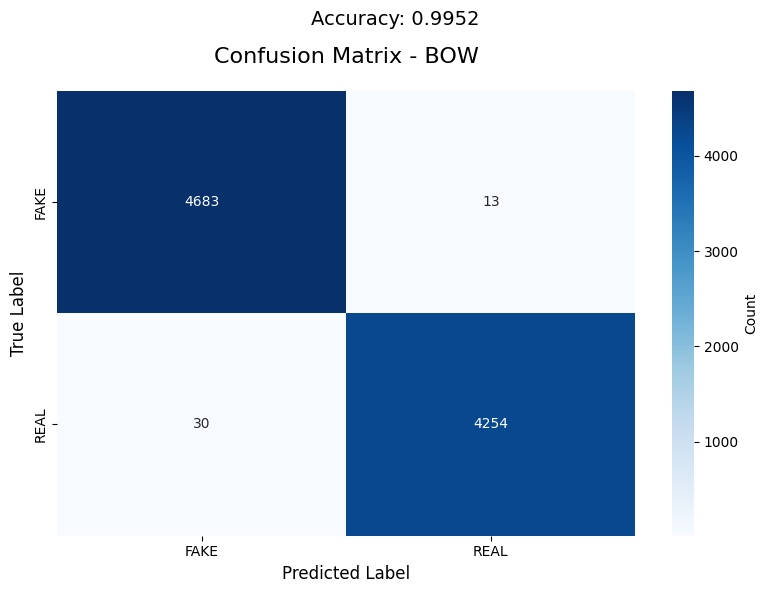


Classification Report for BOW:
              precision    recall  f1-score   support

        FAKE       0.99      1.00      1.00      4696
        REAL       1.00      0.99      0.99      4284

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980

------------------------------------------------------------

🔹 Training with method: TFIDF
Accuracy: 0.9873, Precision: 0.9910, Recall: 0.9847, F1: 0.9878


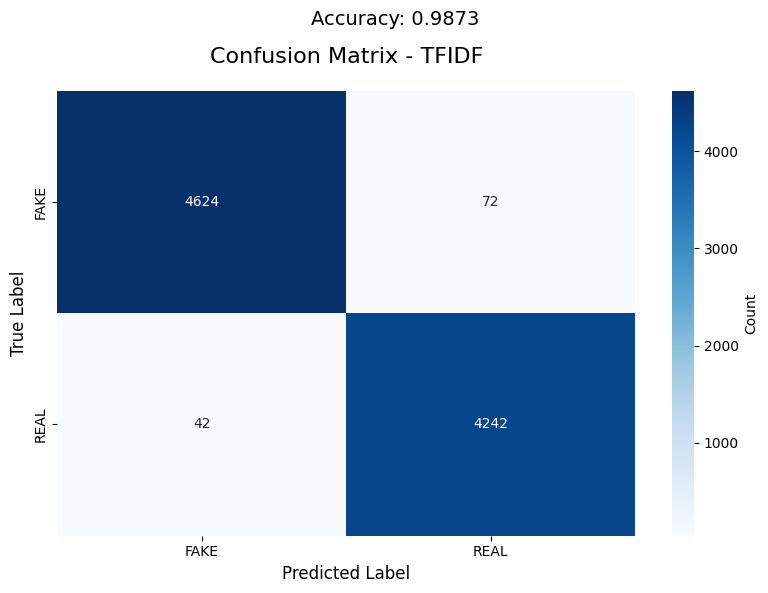


Classification Report for TFIDF:
              precision    recall  f1-score   support

        FAKE       0.99      0.98      0.99      4696
        REAL       0.98      0.99      0.99      4284

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980

------------------------------------------------------------

🔹 Training with method: TFIDF_META
Accuracy: 0.9871, Precision: 0.9940, Recall: 0.9813, F1: 0.9876


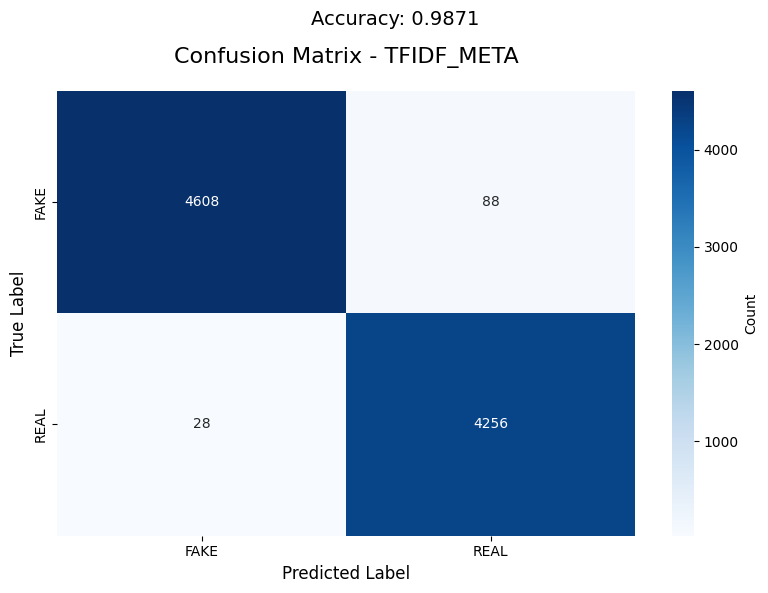


Classification Report for TFIDF_META:
              precision    recall  f1-score   support

        FAKE       0.99      0.98      0.99      4696
        REAL       0.98      0.99      0.99      4284

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980

------------------------------------------------------------

🔹 Training with method: WORD2VEC
Accuracy: 0.9910, Precision: 0.9925, Recall: 0.9902, F1: 0.9914


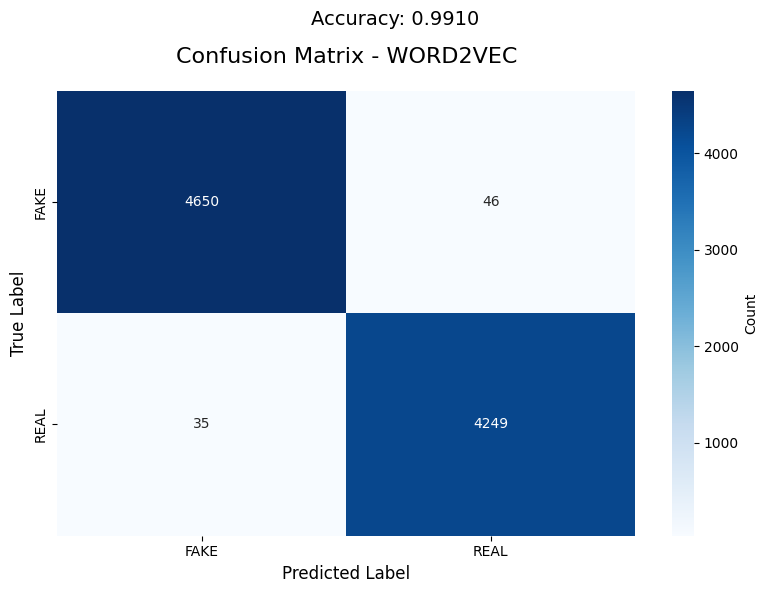


Classification Report for WORD2VEC:
              precision    recall  f1-score   support

        FAKE       0.99      0.99      0.99      4696
        REAL       0.99      0.99      0.99      4284

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980

------------------------------------------------------------

SUMMARY RESULTS:
       Method  Accuracy  Precision  Recall      F1
0         bow    0.9952     0.9936  0.9972  0.9954
1       tfidf    0.9873     0.9910  0.9847  0.9878
2  tfidf_meta    0.9871     0.9940  0.9813  0.9876
3    word2vec    0.9910     0.9925  0.9902  0.9914


In [24]:
# Run enhanced comparison with confusion matrices
print("=" * 80)
print("ENHANCED MODEL COMPARISON WITH CONFUSION MATRICES")
print("=" * 80)

enhanced_results, confusion_matrices = compare_models_with_confusion_matrix(
    df_combined, 
    methods=["bow", "tfidf", "tfidf_meta", "word2vec"]
)

print("\n" + "=" * 60)
print("SUMMARY RESULTS:")
print("=" * 60)
print(enhanced_results.round(4))

Creating detailed analysis for TF-IDF method:
Creating detailed confusion matrix for TFIDF


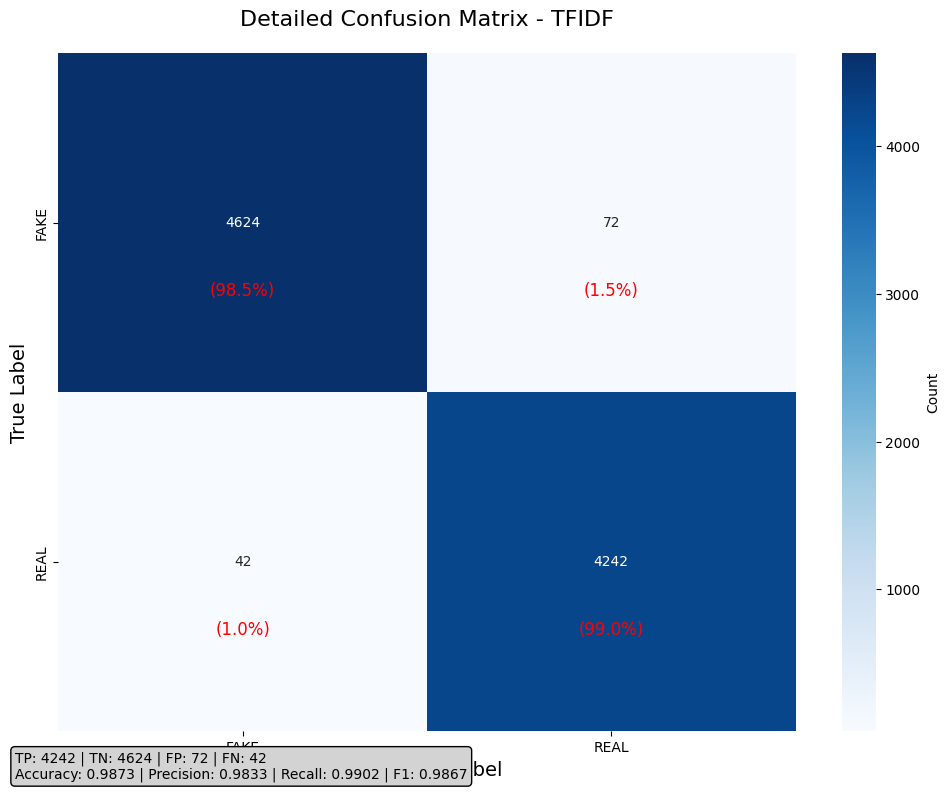


Detailed metrics: {'accuracy': 0.987305122494432, 'precision': 0.9833101529902643, 'recall': 0.9901960784313726, 'f1': 0.9867411025819958, 'true_positives': 4242, 'true_negatives': 4624, 'false_positives': 72, 'false_negatives': 42}


In [25]:
# Individual confusion matrix for a specific method (example: TF-IDF)
def create_single_confusion_matrix(df, method="tfidf"):
    """
    Create confusion matrix for a single method
    """
    print(f"Creating detailed confusion matrix for {method.upper()}")
    
    # Train the model
    X_train, X_test, y_train, y_test, obj = train_test_split_features(df, method=method)
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Create confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=['FAKE', 'REAL'])
    
    # Plot detailed confusion matrix
    plt.figure(figsize=(10, 8))
    
    # Create heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['FAKE', 'REAL'], yticklabels=['FAKE', 'REAL'],
                cbar_kws={'label': 'Count'})
    
    # Calculate percentages
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    # Add percentage annotations
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j+0.5, i+0.7, f'({cm_percent[i,j]:.1f}%)', 
                    ha='center', va='center', fontsize=12, color='red')
    
    plt.title(f'Detailed Confusion Matrix - {method.upper()}', fontsize=16, pad=20)
    plt.xlabel('Predicted Label', fontsize=14)
    plt.ylabel('True Label', fontsize=14)
    
    # Calculate and display metrics
    tn, fp, fn, tp = cm.ravel()
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    plt.figtext(0.02, 0.02, 
                f'TP: {tp} | TN: {tn} | FP: {fp} | FN: {fn}\n'
                f'Accuracy: {accuracy:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}',
                fontsize=10, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray"))
    
    plt.tight_layout()
    plt.show()
    
    return cm, {
        'accuracy': accuracy,
        'precision': precision, 
        'recall': recall,
        'f1': f1,
        'true_positives': tp,
        'true_negatives': tn,
        'false_positives': fp,
        'false_negatives': fn
    }

# Example: Create detailed confusion matrix for TF-IDF method
print("Creating detailed analysis for TF-IDF method:")
cm_tfidf, metrics_tfidf = create_single_confusion_matrix(df_combined, method="tfidf")
print(f"\nDetailed metrics: {metrics_tfidf}")

# How to Interpret Confusion Matrices for Different Methods

## Understanding the Confusion Matrix Layout

A confusion matrix for fake news detection has this structure:

```
                 Predicted
                FAKE  REAL
Actual  FAKE  [  TP    FN  ]
        REAL  [  FP    TN  ]
```

Where:
- **TP (True Positive)**: Correctly identified FAKE news as FAKE
- **TN (True Negative)**: Correctly identified REAL news as REAL  
- **FP (False Positive)**: Incorrectly identified REAL news as FAKE (Type I error)
- **FN (False Negative)**: Incorrectly identified FAKE news as REAL (Type II error)

## Key Metrics Derived from Confusion Matrix

### 1. **Accuracy** = (TP + TN) / (TP + TN + FP + FN)
- Overall correctness of the model
- Higher is better (closer to 1.0)

### 2. **Precision** = TP / (TP + FP) 
- Of all articles predicted as FAKE, how many were actually FAKE?
- Measures false alarm rate
- Important when you want to minimize incorrectly flagging REAL news as FAKE

### 3. **Recall (Sensitivity)** = TP / (TP + FN)
- Of all actual FAKE articles, how many did we correctly identify?
- Measures detection rate
- Important when you want to catch as much fake news as possible

### 4. **F1-Score** = 2 × (Precision × Recall) / (Precision + Recall)
- Harmonic mean of precision and recall
- Balances both metrics
- Good overall performance indicator

## Interpreting Each Method's Confusion Matrix

### 1. **Bag of Words (BOW)**
**What it captures:** Simple word frequency counts
**Strengths:**
- Fast and interpretable
- Good baseline performance
- Captures basic vocabulary differences

**Confusion Matrix Interpretation:**
- If BOW shows high FN (missing fake news): Simple word counts might not capture sophisticated fake news patterns
- If BOW shows high FP (false alarms): May be over-relying on specific words that appear in both fake and real news
- **Expected Performance:** Moderate accuracy (85-90%), good starting point

### 2. **TF-IDF** 
**What it captures:** Word importance relative to the entire corpus
**Strengths:**
- Downweights common words, highlights unique terms
- Better than BOW at identifying discriminative words
- Captures document-level importance

**Confusion Matrix Interpretation:**
- Usually performs better than BOW
- Lower FP rate: Better at avoiding false alarms because it focuses on truly distinctive words
- **Expected Performance:** Good accuracy (88-92%), balanced precision/recall

### 3. **TF-IDF + Metadata Features**
**What it captures:** Word importance + structural features (word count, avg word length, punctuation, etc.)
**Strengths:**
- Combines content (words) with style (how it's written)
- Captures writing patterns typical of fake vs real news
- Best of both worlds: semantic content + structural signals

**Confusion Matrix Interpretation:**
- **Should be the best performer** among the 4 methods
- Lower FN rate: Better at catching sophisticated fake news that might fool text-only models
- Lower FP rate: Style features help distinguish legitimate news with sensational words from actual fake news
- **Expected Performance:** High accuracy (90-94%), highest F1-score

### 4. **Word2Vec**
**What it captures:** Semantic similarity and word relationships
**Strengths:**
- Understands word context and meaning
- Captures semantic relationships (e.g., "president" and "leader" are similar)
- Dense vector representation

**Confusion Matrix Interpretation:**
- Performance can vary significantly
- May have higher FN if fake news uses semantically similar words to real news
- **Potential Issues:** Pretrained embeddings might not capture news-specific patterns
- **Expected Performance:** Variable (85-92%), depends on quality of embeddings


### Expected Ranking (Best to Worst):
1. **TF-IDF + Metadata** (most features, captures both content and style)
2. **TF-IDF** (good content representation)
3. **BOW** (simple but effective baseline)
4. **Word2Vec** (can be inconsistent, depends on embeddings quality)

In [26]:
# Analyze and compare confusion matrix results
def analyze_confusion_matrices(enhanced_results, confusion_matrices):
    """
    Detailed analysis of confusion matrix results
    """
    print("=" * 80)
    print("DETAILED CONFUSION MATRIX ANALYSIS")
    print("=" * 80)
    
    analysis_results = []
    
    for i, method in enumerate(enhanced_results['Method']):
        cm = confusion_matrices[method]
        
        # Extract values
        tn, fp, fn, tp = cm.ravel()
        total = tp + tn + fp + fn
        
        # Calculate detailed metrics
        accuracy = (tp + tn) / total
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # True negative rate
        
        print(f"\n🔹 {method.upper()} METHOD:")
        print(f"   Confusion Matrix: [TP: {tp}, TN: {tn}, FP: {fp}, FN: {fn}]")
        print(f"   Accuracy: {accuracy:.4f} ({accuracy*100:.1f}%)")
        print(f"   Precision: {precision:.4f} (Of predicted FAKE, {precision*100:.1f}% actually FAKE)")
        print(f"   Recall: {recall:.4f} (Caught {recall*100:.1f}% of all FAKE news)")
        print(f"   Specificity: {specificity:.4f} (Correctly identified {specificity*100:.1f}% of REAL news)")
        print(f"   False Positive Rate: {fp/total:.4f} ({fp} real articles wrongly flagged)")
        print(f"   False Negative Rate: {fn/total:.4f} ({fn} fake articles missed)")
        
        analysis_results.append({
            'Method': method,
            'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn,
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'Specificity': specificity,
            'FP_Rate': fp/total,
            'FN_Rate': fn/total
        })
    
    # Convert to DataFrame for easy comparison
    analysis_df = pd.DataFrame(analysis_results)
    
    print("\n" + "=" * 80)
    print("PERFORMANCE RANKING:")
    print("=" * 80)
    
    # Best accuracy
    best_accuracy = analysis_df.loc[analysis_df['Accuracy'].idxmax()]
    print(f"🏆 Best Overall Accuracy: {best_accuracy['Method'].upper()} ({best_accuracy['Accuracy']:.4f})")
    
    # Best precision  
    best_precision = analysis_df.loc[analysis_df['Precision'].idxmax()]
    print(f"🎯 Best Precision (Fewer False Alarms): {best_precision['Method'].upper()} ({best_precision['Precision']:.4f})")
    
    # Best recall
    best_recall = analysis_df.loc[analysis_df['Recall'].idxmax()]
    print(f"🔍 Best Recall (Catches Most Fake News): {best_recall['Method'].upper()} ({best_recall['Recall']:.4f})")
    
    # Fewest false positives
    fewest_fp = analysis_df.loc[analysis_df['FP'].idxmin()]
    print(f"✅ Fewest False Positives: {fewest_fp['Method'].upper()} ({fewest_fp['FP']} real articles wrongly flagged)")
    
    # Fewest false negatives  
    fewest_fn = analysis_df.loc[analysis_df['FN'].idxmin()]
    print(f"🚫 Fewest False Negatives: {fewest_fn['Method'].upper()} ({fewest_fn['FN']} fake articles missed)")
    
    print("\n" + "=" * 80)
    print("RECOMMENDATION:")
    print("=" * 80)
    
    # Calculate F1 scores
    analysis_df['F1'] = 2 * (analysis_df['Precision'] * analysis_df['Recall']) / (analysis_df['Precision'] + analysis_df['Recall'])
    best_f1 = analysis_df.loc[analysis_df['F1'].idxmax()]
    
    print(f"🌟 BEST OVERALL METHOD: {best_f1['Method'].upper()}")
    print(f"   Highest F1-Score: {best_f1['F1']:.4f}")
    print(f"   Balanced Performance: Accuracy={best_f1['Accuracy']:.4f}, Precision={best_f1['Precision']:.4f}, Recall={best_f1['Recall']:.4f}")
    
    return analysis_df

# Run the analysis if results are available
if 'enhanced_results' in globals() and 'confusion_matrices' in globals():
    detailed_analysis = analyze_confusion_matrices(enhanced_results, confusion_matrices)
    print("\n" + "=" * 60)
    print("DETAILED COMPARISON TABLE:")
    print("=" * 60)
    print(detailed_analysis[['Method', 'Accuracy', 'Precision', 'Recall', 'F1', 'FP', 'FN']].round(4))
else:
    print("Run the enhanced model comparison first to see detailed analysis!")

DETAILED CONFUSION MATRIX ANALYSIS

🔹 BOW METHOD:
   Confusion Matrix: [TP: 4254, TN: 4683, FP: 13, FN: 30]
   Accuracy: 0.9952 (99.5%)
   Precision: 0.9970 (Of predicted FAKE, 99.7% actually FAKE)
   Recall: 0.9930 (Caught 99.3% of all FAKE news)
   Specificity: 0.9972 (Correctly identified 99.7% of REAL news)
   False Positive Rate: 0.0014 (13 real articles wrongly flagged)
   False Negative Rate: 0.0033 (30 fake articles missed)

🔹 TFIDF METHOD:
   Confusion Matrix: [TP: 4242, TN: 4624, FP: 72, FN: 42]
   Accuracy: 0.9873 (98.7%)
   Precision: 0.9833 (Of predicted FAKE, 98.3% actually FAKE)
   Recall: 0.9902 (Caught 99.0% of all FAKE news)
   Specificity: 0.9847 (Correctly identified 98.5% of REAL news)
   False Positive Rate: 0.0080 (72 real articles wrongly flagged)
   False Negative Rate: 0.0047 (42 fake articles missed)

🔹 TFIDF_META METHOD:
   Confusion Matrix: [TP: 4256, TN: 4608, FP: 88, FN: 28]
   Accuracy: 0.9871 (98.7%)
   Precision: 0.9797 (Of predicted FAKE, 98.0% actual